# AppliSourceion 2 — Texture Transfer

Once we have a correspondence between two shapes we can transfer any per-vertex attribute — colors,
textures, signals — from one shape to the other.

We compare two transfer strategies:
- **Point-to-point (direct)**: `f_b[i] = f_a[p2p[i]]`  — fast but can be noisy.
- **Spectral (via FM)**: project → multiply by C → reconstruct — smoother, naturally
  band-limited by the basis.

In [1]:
import gsops.backend as gs
import numpy as np
import pyvista as pv

from geomfum.convert import P2pFromFmConverter
from geomfum.dataset import NotebooksDataset
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature, WaveKernelSignature
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize
from geomfum.refine import IcpRefiner
from geomfum.shape import TriangleMesh

pv.set_jupyter_backend("static")


def to_pv(mesh):
    faces = np.hstack([np.full((len(mesh.faces), 1), 3), mesh.faces])
    return pv.PolyData(np.array(mesh.vertices), faces)

## 1. Load shapes and compute correspondence

In [15]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(dataset.get_filename("faust-00"))  # textured source
mesh_b = TriangleMesh.from_file(dataset.get_filename("faust-04"))  # target

k = 200
mesh_a.laplacian.find_spectrum(spectrum_size=k, set_as_basis=True)
mesh_b.laplacian.find_spectrum(spectrum_size=k, set_as_basis=True)

mesh_a.landmark_indices = gs.array([1000, 2000, 3000, 4000, 5000, 6000])
mesh_b.landmark_indices = gs.array([1000, 2000, 3000, 4000, 5000, 6000])

pipeline = DescriptorPipeline(
    [
        WaveKernelSignature.from_registry(n_domain=100),
        LandmarkWaveKernelSignature.from_registry(n_domain=100),
        ArangeSubsampler(subsample_step=10),
        L2InnerNormalizer(),
    ]
)
descr_a = pipeline.apply(mesh_a)
descr_b = pipeline.apply(mesh_b)

mesh_a.basis.use_k = 30
mesh_b.basis.use_k = 30

factors = [
    SpectralDescriptorPreservation(
        mesh_a.basis.project(descr_a),
        mesh_b.basis.project(descr_b),
        weight=1.0,
    ),
    LBCommutativityEnforcing.from_bases(mesh_a.basis, mesh_b.basis, weight=1e-2),
]
x0 = gs.zeros((mesh_b.basis.use_k, mesh_a.basis.use_k))
res = ScipyMinimize(method="L-BFGS-B").minimize(
    FactorSum(factors), x0, fun_jac=FactorSum(factors).gradient
)
fmap = res.x.reshape(x0.shape)
fmap = IcpRefiner()(fmap, mesh_a.basis, mesh_b.basis)
p2p = P2pFromFmConverter()(fmap, mesh_a.basis, mesh_b.basis)

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-00.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\faust-04.off').


## 2. Define a synthetic texture on the Source

We use a sinusoidal stripe pattern derived from the surface coordinates.
Replace this with any per-vertex color or signal you have.

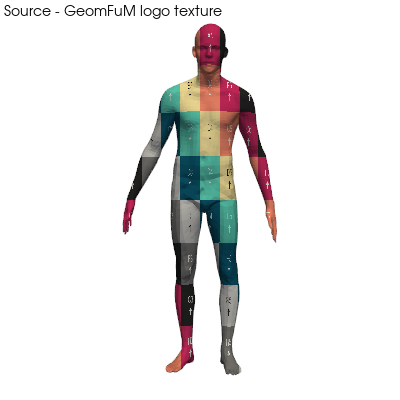

In [62]:
from pathlib import Path


def generate_tex_coords(verts, col1=1, col2=0, mult_const=1):
    ind = np.argsort(np.std(verts, axis=0))[::-1]
    verts = verts[:, ind]
    vt = np.stack([verts[:, col1], verts[:, col2]], axis=-1)
    vt -= np.min(vt, axis=0, keepdims=True)
    vt = mult_const * vt / np.max(vt)
    vt[:, 0] = (vt[:, 0] - vt[:, 0].min()) / (vt[:, 0].max() - vt[:, 0].min())
    vt[:, 1] = (vt[:, 1] - vt[:, 1].min()) / (vt[:, 1].max() - vt[:, 1].min())
    return vt


pv_a = to_pv(mesh_a)
texture_a = generate_tex_coords(np.array(mesh_a.vertices))
pv_a.active_texture_coordinates = texture_a

texture_path = Path("./texture.png")
texture_image = pv.read_texture(str(texture_path))

# Keep a scalar texture for the transfer steps below (p2p/FM).
img = texture_image.to_array().astype(np.float32)
if img.max() > 1.0:
    img /= 255.0
if img.shape[-1] == 4:
    img = img[..., :3]


pl = pv.Plotter(window_size=(400, 400))
pl.add_mesh(pv_a, texture=texture_image, show_scalar_bar=False)
pl.add_text("Source - GeomFuM logo texture", font_size=10)
pl.camera_position = "xy"
pl.show()

## 3. Transfer via point-to-point correspondence

Direct indexing: each Target vertex takes the color of its corresponding Source vertex.

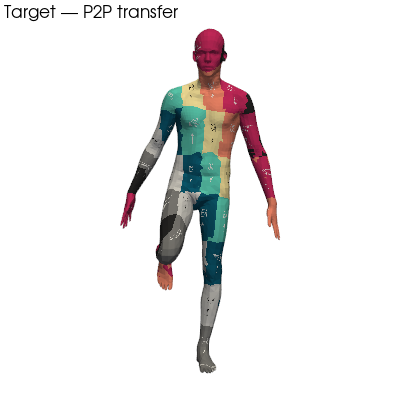

In [63]:
pl = pv.Plotter(window_size=(400, 400))
pv_b = to_pv(mesh_b)
pv_b.active_texture_coordinates = texture_b_p2p = texture_a[p2p]

pl.add_mesh(pv_b, texture=texture_image, show_scalar_bar=False)

pl.add_text("Target — P2P transfer", font_size=10)
pl.camera_position = "xy"
pl.show()

## 4. Transfer via functional map (spectral)

Project the texture onto A's spectral basis, apply C, reconstruct on B.
The result is naturally smooth and band-limited.

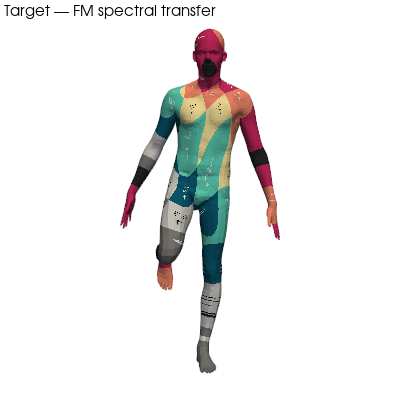

In [64]:
# Project texture onto Source's basis
coeff_a = mesh_a.basis.project(texture_a.T).T  # (K_a,)
# Apply functional map
coeff_b = np.array(fmap) @ coeff_a  # (K_b,)
# Reconstruct on Target
texture_b_fm = np.array(mesh_b.basis.vecs) @ coeff_b  # (n_b,)

pl = pv.Plotter(window_size=(400, 400))
pv_b2 = to_pv(mesh_b)
pv_b2.active_texture_coordinates = texture_b_fm
pl.add_mesh(pv_b2, texture=texture_image)
pl.add_text("Target — FM spectral transfer", font_size=10)
pl.camera_position = "xy"
pl.show()

## 5. Side-by-side comparison

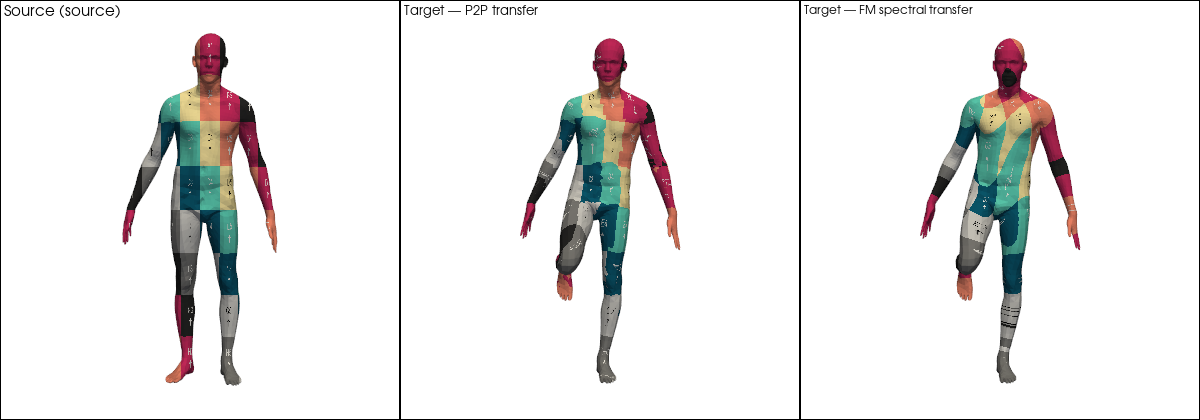

In [65]:
pl = pv.Plotter(shape=(1, 3), window_size=(1200, 420))
clim = [texture_a.min(), texture_a.max()]

pl.subplot(0, 0)
pv_a.active_texture_coordinates = texture_a

pl.add_mesh(pv_a.copy(), texture=texture_image, show_scalar_bar=False)
pl.add_text("Source (source)", font_size=9)
pl.camera_position = "xy"

pl.subplot(0, 1)
pv_c1 = to_pv(mesh_b)
pv_c1.active_texture_coordinates = texture_b_p2p
pl.add_mesh(pv_c1, texture=texture_image, show_scalar_bar=False)
pl.add_text("Target — P2P transfer", font_size=9)
pl.camera_position = "xy"

pl.subplot(0, 2)
pv_c2 = to_pv(mesh_b)
pv_c2.active_texture_coordinates = texture_b_fm
pl.add_mesh(pv_c2, texture=texture_image, show_scalar_bar=False)
pl.add_text("Target — FM spectral transfer", font_size=9)
pl.camera_position = "xy"

pl.show()

The FM spectral transfer (right) is smoother than the direct P2P transfer (middle)
because it is limited to the first `k` frequency components of the basis.